# CardioScope-XAI â€” Exploratory Data Analysis
**Dataset:** UCI Cleveland Heart Disease (303 patients, 13 clinical features)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_and_clean, FEATURE_COLUMNS, CATEGORICAL_FEATURES, CONTINUOUS_FEATURES

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [2]:
df = load_and_clean('../data/raw/heart_disease_uci.csv')
df.head()

[data_loader] Using 'Cleveland' subset: 304 rows.
[data_loader] Dropped 7 rows with missing values.
[data_loader] Clean dataset: 297 rows, 14 columns.
[data_loader] Class balance — 0 (no disease): 160, 1 (disease): 137


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


In [3]:
print(f'Shape: {df.shape}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')

Shape: (297, 14)

Dtypes:
age           int64
sex           int32
cp            int32
trestbps    float64
chol        float64
fbs           int32
restecg       int32
thalach     float64
exang         int32
oldpeak     float64
slope         int32
ca            int32
thal          int32
target        int32
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.54,9.05,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.69,17.76,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.35,52.00,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
restecg,297.0,1.00,0.99,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.60,22.94,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.06,1.17,0.0,0.0,0.8,1.6,6.2


## 2. Target Distribution

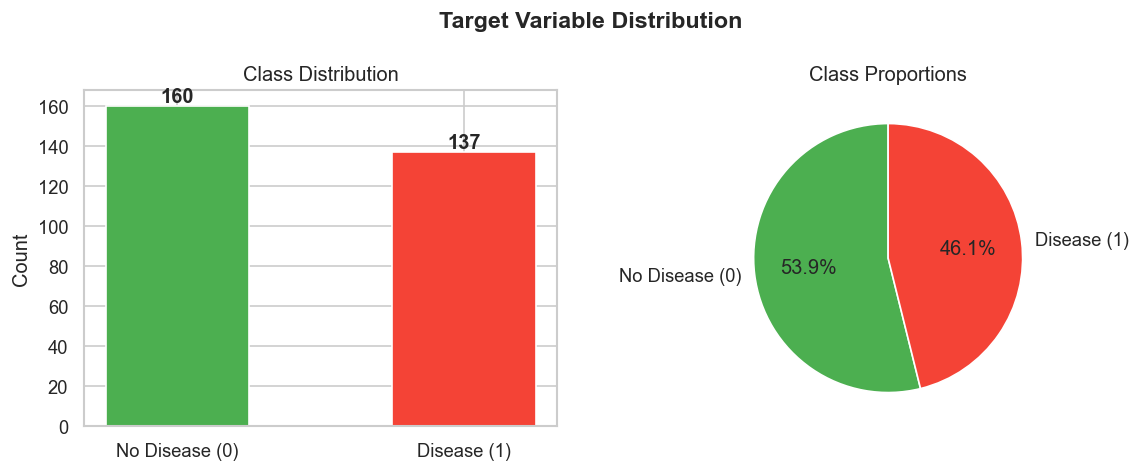

Class imbalance ratio: 1.17


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']

axes[0].bar(labels, counts.values, color=['#4CAF50', '#F44336'], width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Class Proportions')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Class imbalance ratio: {counts[0]/counts[1]:.2f}')

## 3. Continuous Feature Distributions

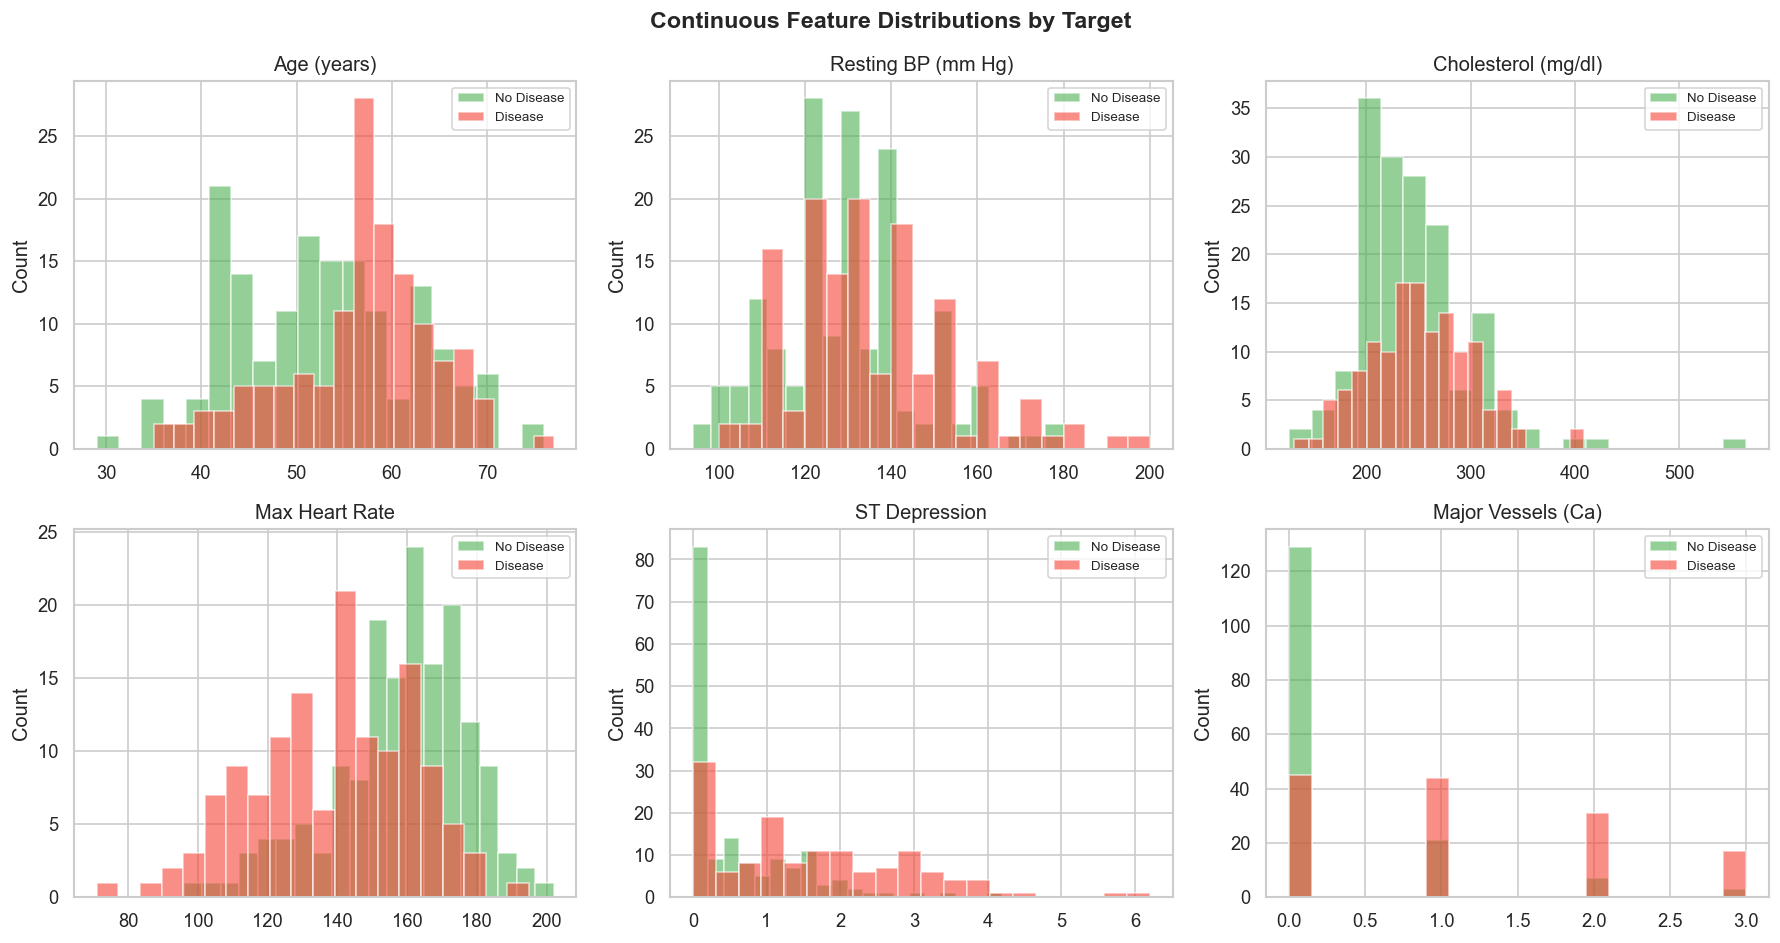

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cont_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
feature_labels = {
    'age': 'Age (years)',
    'trestbps': 'Resting BP (mm Hg)',
    'chol': 'Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate',
    'oldpeak': 'ST Depression',
    'ca': 'Major Vessels (Ca)'
}

for i, feat in enumerate(cont_features):
    for target_val, color, label in [(0, '#4CAF50', 'No Disease'), (1, '#F44336', 'Disease')]:
        axes[i].hist(df[df['target'] == target_val][feat], bins=20,
                     alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feature_labels[feat])
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

plt.suptitle('Continuous Feature Distributions by Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis

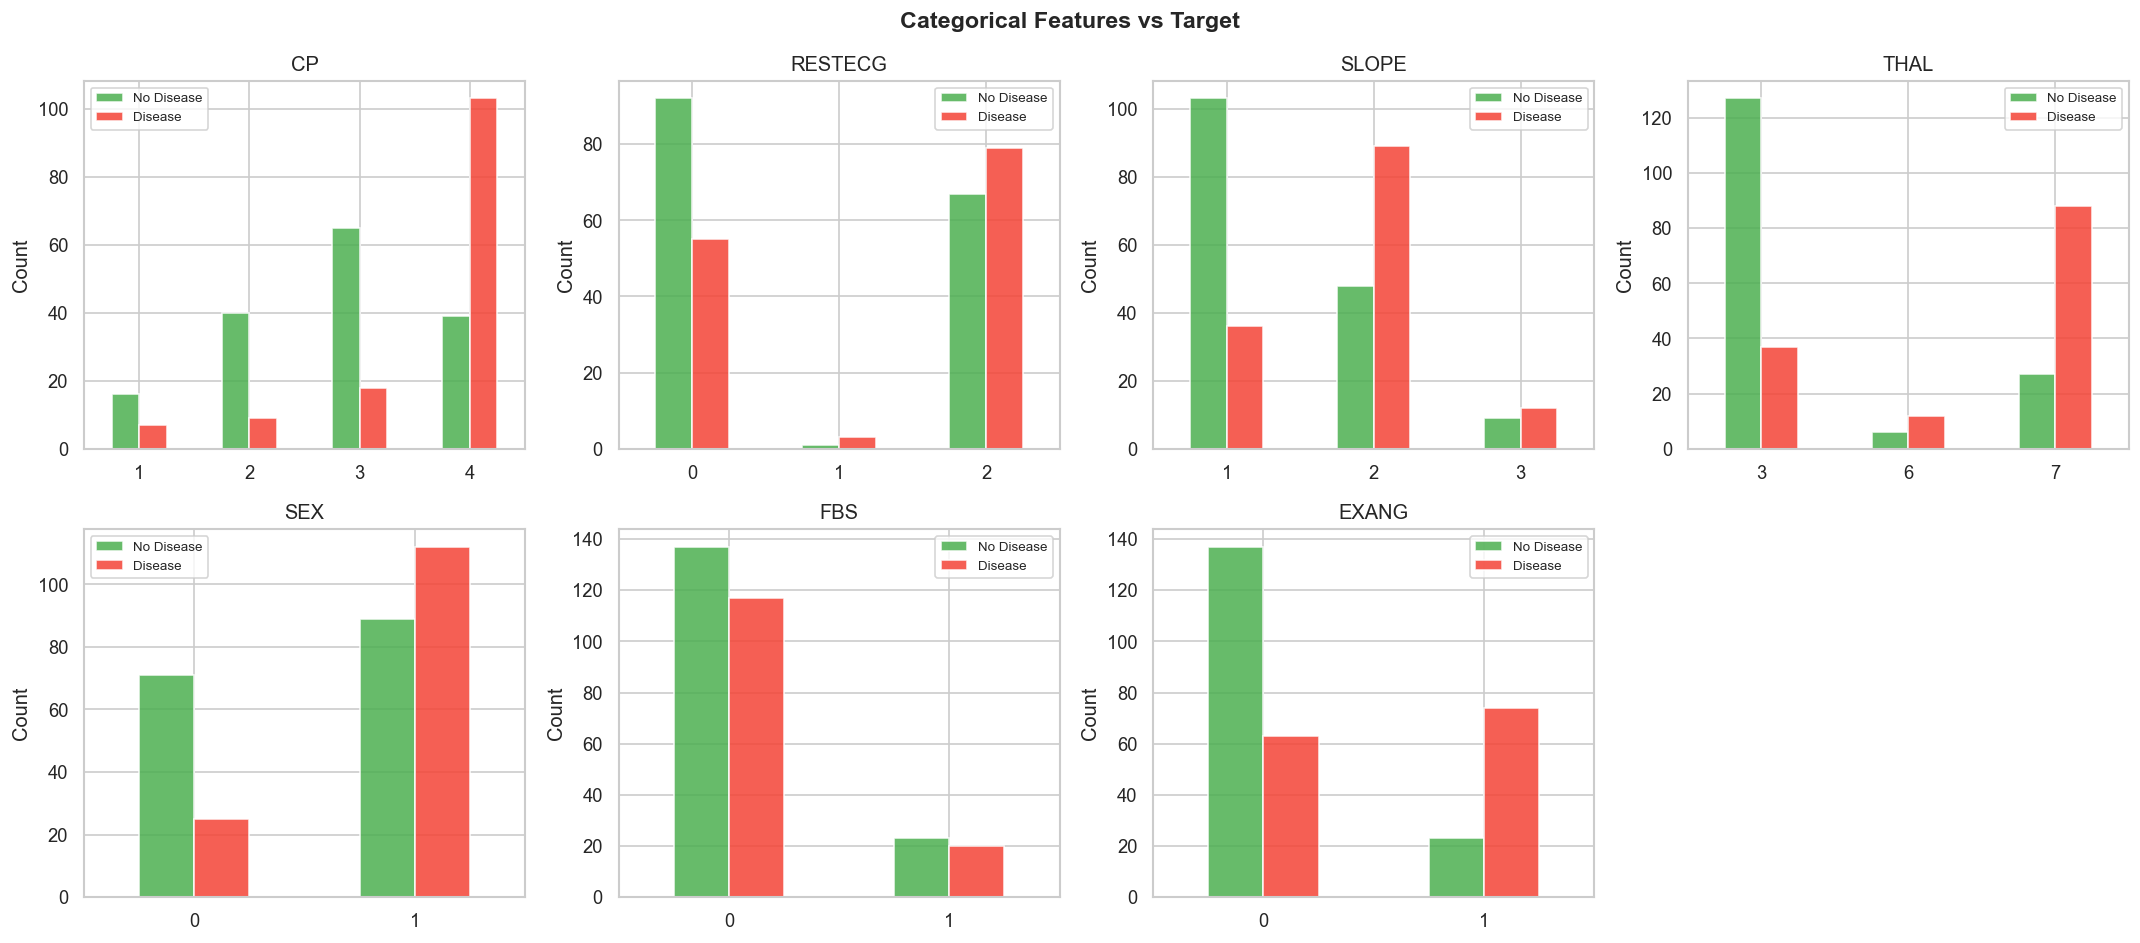

In [7]:
cat_features = {
    'cp':      ['Typical Angina', 'Atypical Angina', 'Non-Anginal', 'Asymptomatic'],
    'restecg': ['Normal', 'ST-T Abnormality', 'LV Hypertrophy'],
    'slope':   ['Upsloping', 'Flat', 'Downsloping'],
    'thal':    ['Normal (3)', 'Fixed Defect (6)', 'Reversable Defect (7)'],
    'sex':     ['Female', 'Male'],
    'fbs':     ['FBS â‰¤120', 'FBS >120'],
    'exang':   ['No Angina', 'Exercise Angina']
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (feat, _) in enumerate(cat_features.items()):
    ct = pd.crosstab(df[feat], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='white', alpha=0.85)
    axes[i].set_title(feat.upper())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

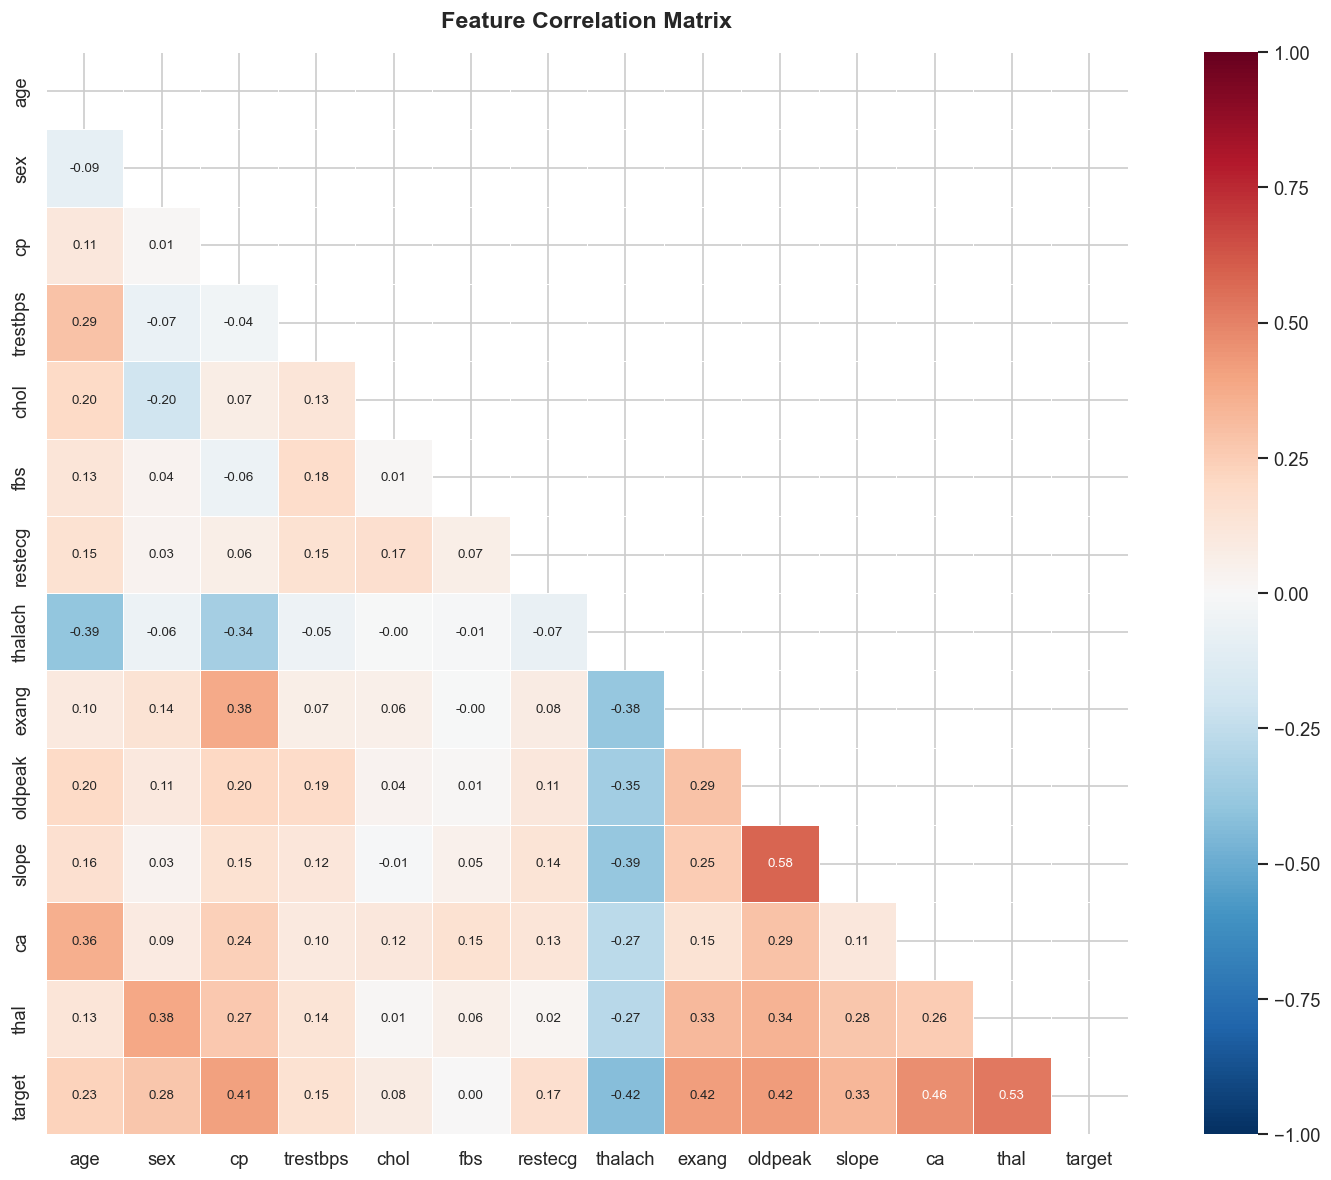

In [8]:
fig, ax = plt.subplots(figsize=(13, 10))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}, vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Feature Correlation with Target

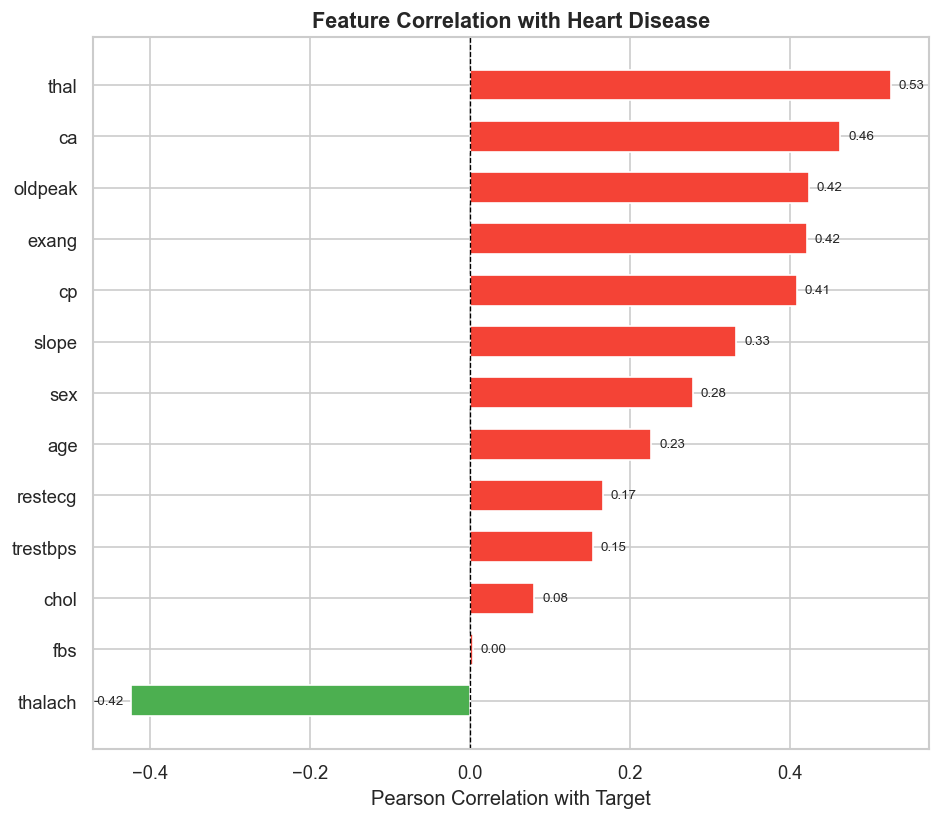

Top 5 risk-increasing features:
cp         0.408945
exang      0.421355
oldpeak    0.424052
ca         0.463189
thal       0.526640

Top 5 risk-reducing features:
thalach    -0.423817
fbs         0.003167
chol        0.080285
trestbps    0.153490
restecg     0.166343


In [9]:
target_corr = df.corr()['target'].drop('target').sort_values()

colors = ['#F44336' if v > 0 else '#4CAF50' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pearson Correlation with Target')
ax.set_title('Feature Correlation with Heart Disease', fontsize=13, fontweight='bold')

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('Top 5 risk-increasing features:')
print(target_corr.tail(5).to_string())
print('\nTop 5 risk-reducing features:')
print(target_corr.head(5).to_string())

## 7. Boxplots â€” Continuous Features by Target

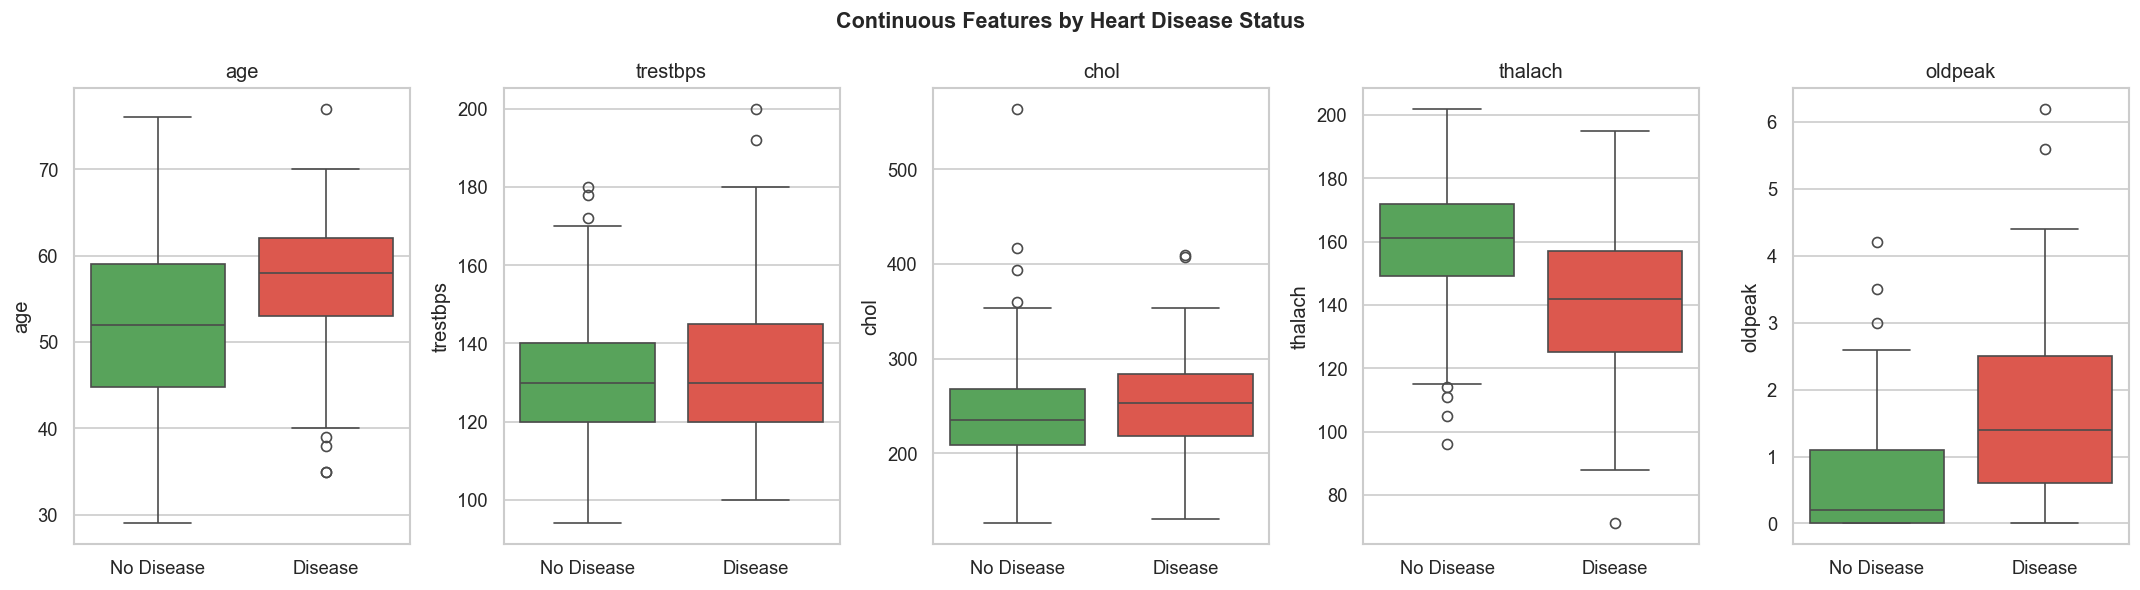

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, feat in enumerate(['age', 'trestbps', 'chol', 'thalach', 'oldpeak']):
    sns.boxplot(
        data=df, x='target', y=feat, ax=axes[i],
        hue='target',
        palette={0: '#4CAF50', 1: '#F44336'},
        legend=False
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Key EDA Findings

| Finding | Implication |
|---|---|
| `thalach` (max HR) negatively correlated with disease | Lower max HR â†’ higher risk |
| `cp` type 4 (asymptomatic) strongly associated with disease | Counter-intuitive â€” silent ischemia |
| `oldpeak` (ST depression) positively correlated | Key exercise stress marker |
| `ca` (vessels colored) positively correlated | More blocked vessels â†’ higher risk |
| `exang` (exercise angina) positively correlated | Pain during exercise = risk signal |
| Class balance is ~54% No Disease / 46% Disease | Relatively balanced â€” no heavy resampling needed |